In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("twitter.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [7]:
df.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df['label'].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

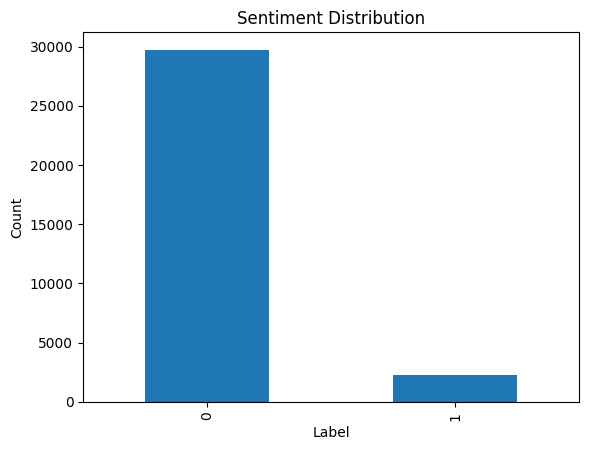

In [10]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [11]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_tweet'] = df['tweet'].apply(clean_text)

df[['tweet', 'clean_tweet']].head()

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i cant use cause they...
2,bihday your majesty,bihday your majesty
3,#model i love u take with u all the time in ...,model i love u take with u all the time in u...
4,factsguide: society now #motivation,factsguide society now motivation


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(df['clean_tweet'])

y = df['label']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9499452526200531
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.92      0.33      0.48       456

    accuracy                           0.95      6393
   macro avg       0.94      0.66      0.73      6393
weighted avg       0.95      0.95      0.94      6393



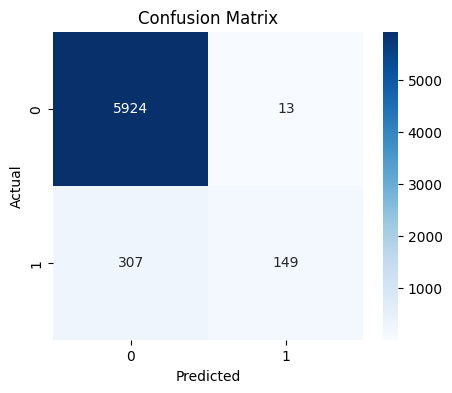

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
sample = ["I love this product. It is amazing!"]

sample_clean = [clean_text(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

prediction = model.predict(sample_vector)

if prediction[0] == 0:
    print("Positive Tweet 😊")
else:
    print("Negative Tweet 😠")

Positive Tweet 😊


In [20]:
df["label"].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

In [21]:
if prediction[0] == 1:
    print("Positive Tweet 😊")
else:
    print("Negative Tweet 😡")

Negative Tweet 😡


In [22]:
if prediction[0] == 0:
    print("Positive Tweet 😊")
else:
    print("Negative Tweet 😡")

Positive Tweet 😊


In [23]:
prediction

array([0], dtype=int64)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

In [25]:
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9206945096198967
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      5937
           1       0.47      0.80      0.59       456

    accuracy                           0.92      6393
   macro avg       0.73      0.87      0.77      6393
weighted avg       0.95      0.92      0.93      6393



In [27]:
sample = ["I love this product. It is amazing!"]

sample_clean = [clean_text(text) for text in sample]
sample_vector = tfidf.transform(sample_clean)

prediction = model.predict(sample_vector)

if prediction[0] == 0:
    print("Positive Tweet 😊")
else:
    print("Negative Tweet 😡")

Positive Tweet 😊


In [29]:
sample = ["I hate this product. Worst experience ever."]

sample_clean = [clean_text(text) for text in sample]
sample_vector = tfidf.transform(sample_clean)

prediction = model.predict(sample_vector)

if prediction[0] == 0:
    print("Positive Tweet 😊")
else:
    print("Negative Tweet 😡")

Negative Tweet 😡
